<a href="https://colab.research.google.com/github/Saisohangoud/quick-commerce-analytics-dashboard/blob/main/Quick_Commerce_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS
     order_id  customer_id           order_date promised_delivery_time  \
0  1961864118     30065862  2024-07-17 08:34:01    2024-07-17 08:52:01   
1  1549769649      9573071  2024-05-28 13:14:29    2024-05-28 13:25:29   
2  9185164487     45477575  2024-09-23 13:07:12    2024-09-23 13:25:12   
3  9644738826     88067569  2023-11-24 16:16:56    2023-11-24 16:34:56   
4  5427684290     83298567  2023-11-20 05:00:39    2023-11-20 05:17:39   

  actual_delivery_time delivery_status  order_total payment_method  \
0  2024-07-17 08:47:01         On Time      3197.07           Cash   
1  2024-05-28 13:27:29         On Time       976.55           Cash   
2  2024-09-23 13:29:12         On Time       839.05            UPI   
3  2023-11-24 16:33:56         On Time       440.23           Card   
4  2023-11-20 05:18:39         On Time      2526.68           Cash   

   delivery_partner_id  store_id  
0                63230      4771  
1                14983      7534  
2               

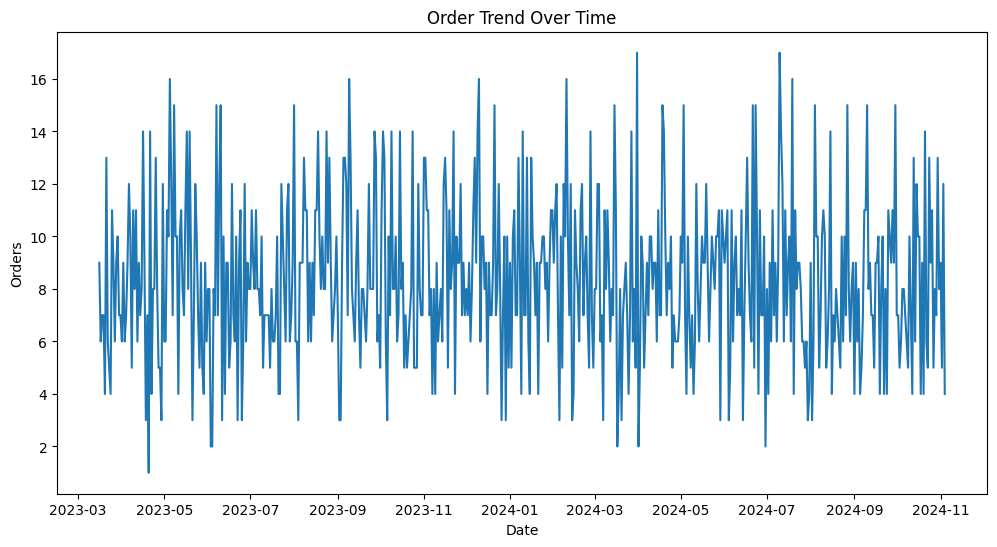

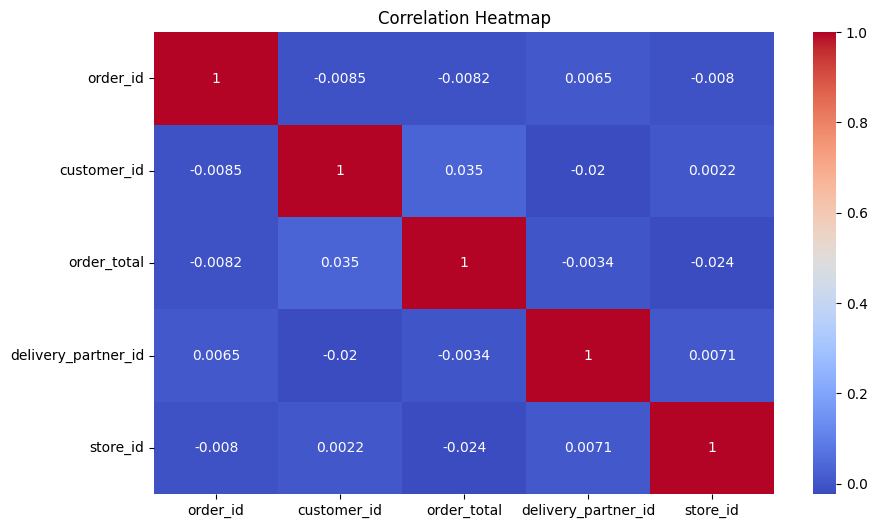


PROJECT INSIGHTS
--------------------------------
1. Customer purchasing patterns can be analyzed using order trends.
2. Sales distribution helps identify revenue concentration.
3. City-wise analysis identifies top-performing regions.
4. Correlation analysis reveals relationships between business metrics.
5. Quick commerce analytics helps improve operational decisions.

CLEANED DATA EXPORTED SUCCESSFULLY


In [1]:
# ==========================================
# QUICK COMMERCE ANALYTICS PROJECT
# Blinkit / Zepto Style Dashboard Analysis
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# LOAD DATASET
# ------------------------------------------

df = pd.read_csv("blinkit_orders.csv")

# ------------------------------------------
# BASIC DATASET INFORMATION
# ------------------------------------------

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())

# ------------------------------------------
# DATA CLEANING
# ------------------------------------------

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna(0, inplace=True)

print("\nDATA CLEANED SUCCESSFULLY")

# ------------------------------------------
# DATASET SUMMARY
# ------------------------------------------

print("\nDATASET STATISTICS")
print(df.describe())

# ------------------------------------------
# CHECK AVAILABLE COLUMNS
# ------------------------------------------

print("\nAVAILABLE COLUMNS:")
for col in df.columns:
    print(col)

# ------------------------------------------
# SALES ANALYSIS
# (Adjust column names if needed)
# ------------------------------------------

# Try detecting amount/sales column automatically

sales_column = None

possible_sales_columns = [
    'sales',
    'Sales',
    'amount',
    'Amount',
    'total_amount',
    'Total_Amount',
    'order_amount'
]

for col in possible_sales_columns:
    if col in df.columns:
        sales_column = col
        break

if sales_column:

    print(f"\nSALES COLUMN DETECTED: {sales_column}")

    # Total Revenue
    total_revenue = df[sales_column].sum()

    print("\nTOTAL REVENUE")
    print(total_revenue)

    # ------------------------------------------
    # SALES DISTRIBUTION GRAPH
    # ------------------------------------------

    plt.figure(figsize=(10,6))

    sns.histplot(df[sales_column], bins=30)

    plt.title("Sales Distribution")

    plt.xlabel("Sales")

    plt.ylabel("Frequency")

    plt.show()

else:
    print("\nNo sales column detected automatically.")

# ------------------------------------------
# CITY ANALYSIS
# ------------------------------------------

possible_city_columns = [
    'city',
    'City',
    'location'
]

city_column = None

for col in possible_city_columns:
    if col in df.columns:
        city_column = col
        break

if city_column and sales_column:

    city_sales = df.groupby(city_column)[sales_column].sum().sort_values(
        ascending=False
    ).head(10)

    print("\nTOP CITIES BY SALES")
    print(city_sales)

    plt.figure(figsize=(12,6))

    city_sales.plot(kind='bar')

    plt.title("Top Cities by Sales")

    plt.xlabel("City")

    plt.ylabel("Sales")

    plt.xticks(rotation=45)

    plt.show()

# ------------------------------------------
# ORDER TREND ANALYSIS
# ------------------------------------------

possible_date_columns = [
    'order_date',
    'Order_Date',
    'date',
    'Date'
]

date_column = None

for col in possible_date_columns:
    if col in df.columns:
        date_column = col
        break

if date_column:

    try:
        df[date_column] = pd.to_datetime(df[date_column])

        orders_by_date = df.groupby(
            df[date_column].dt.date
        ).size()

        plt.figure(figsize=(12,6))

        orders_by_date.plot()

        plt.title("Order Trend Over Time")

        plt.xlabel("Date")

        plt.ylabel("Orders")

        plt.show()

    except:
        print("\nDate conversion issue.")

# ------------------------------------------
# CORRELATION HEATMAP
# ------------------------------------------

numeric_df = df.select_dtypes(include=np.number)

if not numeric_df.empty:

    plt.figure(figsize=(10,6))

    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title("Correlation Heatmap")

    plt.show()

# ------------------------------------------
# FINAL INSIGHTS
# ------------------------------------------

print("\nPROJECT INSIGHTS")
print("--------------------------------")

print("1. Customer purchasing patterns can be analyzed using order trends.")

print("2. Sales distribution helps identify revenue concentration.")

print("3. City-wise analysis identifies top-performing regions.")

print("4. Correlation analysis reveals relationships between business metrics.")

print("5. Quick commerce analytics helps improve operational decisions.")

# ------------------------------------------
# EXPORT CLEANED DATA
# ------------------------------------------

df.to_csv("cleaned_blinkit_orders.csv", index=False)

print("\nCLEANED DATA EXPORTED SUCCESSFULLY")